# ANN cu tool

## Rezolvarea unor probleme de clasificare prin metode de învățare automată

Cerintele laboratorului:
- crearea unui set de date (imagini + etichetarea corespunzatoare)
- antrenarea unui model si testarea lui pentru clasificarea imaginilor normale vs sepia
     1. ANN (Artificial Neural Network) cu tool
     2. influenta (hyper)parametrilor
     3. ANN cod propriu
     4. CNN (Convolutional Neural Network) cod propriu

Steps:
1. Load data
2. Impartirea setului de date in train si test + verificarea echilibrului setului de date
3. Invatarea modelului
4. Testarea modelului + vizualizarea datelor
5. Metrici de performanta

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn import neural_network
import matplotlib.pyplot as plt
from sklearn import neural_network
from sklearn import linear_model

### Step 1 + Step 2

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv("metadata.csv")

train_df, test_df = train_test_split(
    df,
    # ia 20% din date pentru test
    test_size=0.20,
    # asemanator cu seed-ul de la random
    random_state=42,
    # pastreaza un echilibru intre labeluri (50% sepia, 50% noSepia)
    stratify=df['label']
)

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [3]:
import os
from PIL import Image

# transforma imaginile in array-uri de numere
def load_images_from_df(df, folder):
    images = []
    for filename in df['filename']:
        path = os.path.join(folder, filename)
        # Deschidem, ne asigurăm că e RGB și transformăm în array de numere
        img = Image.open(path).convert('RGB')
        img_array = np.asarray(img)
        images.append(img_array)
    return np.array(images)


folder_date = 'processedImages64'

trainInputs = load_images_from_df(train_df, folder_date)
testInputs = load_images_from_df(test_df, folder_date)

trainOutputs = train_df['label'].map({'sepia': 1, 'noSepia': 0}).values
testOutputs = test_df['label'].map({'sepia': 1, 'noSepia': 0}).values

outputNames = ['noSepia','sepia']


def normalisation(trainData, testData):
    trainData = trainData.astype('float32') / 255.0
    testData = testData.astype('float32') / 255.0
    return trainData, testData

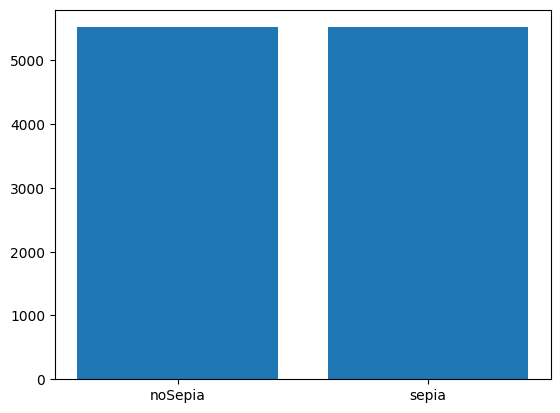

In [4]:
# check if the data is uniform distributed over classes
bins = range(3)
plt.hist(trainOutputs, bins, rwidth = 0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins)+bin_w/2, max(bins), bin_w), outputNames)
plt.show()

# np.reshape pentru a face calculele mai rapid
trainInputsFlatten = trainInputs.reshape(trainInputs.shape[0], -1)
testInputsFlatten = testInputs.reshape(testInputs.shape[0], -1)
trainInputsNormalised, testInputsNormalised = normalisation(trainInputsFlatten, testInputsFlatten)

### Step 3 -> Invatarea modelului

In [5]:
classifier = neural_network.MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', max_iter=100, solver='adam', verbose=True, random_state=1, learning_rate_init=.001)

classifier.fit(trainInputsNormalised, trainOutputs)

Iteration 1, loss = 0.94558561
Iteration 2, loss = 0.58060847
Iteration 3, loss = 0.51858861
Iteration 4, loss = 0.44215674
Iteration 5, loss = 0.38499018
Iteration 6, loss = 0.29824836
Iteration 7, loss = 0.25227242
Iteration 8, loss = 0.23559763
Iteration 9, loss = 0.21075423
Iteration 10, loss = 0.19021623
Iteration 11, loss = 0.20087618
Iteration 12, loss = 0.19107159
Iteration 13, loss = 0.17924314
Iteration 14, loss = 0.16370403
Iteration 15, loss = 0.15079897
Iteration 16, loss = 0.14010137
Iteration 17, loss = 0.15709695
Iteration 18, loss = 0.12704079
Iteration 19, loss = 0.14928837
Iteration 20, loss = 0.17013524
Iteration 21, loss = 0.12976467
Iteration 22, loss = 0.11415667
Iteration 23, loss = 0.10506699
Iteration 24, loss = 0.10965683
Iteration 25, loss = 0.10564064
Iteration 26, loss = 0.10703596
Iteration 27, loss = 0.10084451
Iteration 28, loss = 0.25639243
Iteration 29, loss = 0.13248188
Iteration 30, loss = 0.10706761
Iteration 31, loss = 0.10032845
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


### Step 4 -> Testarea modelului

In [6]:
predictedLabels = classifier.predict(testInputsNormalised)

### Step 5 -> Metrici de performanta

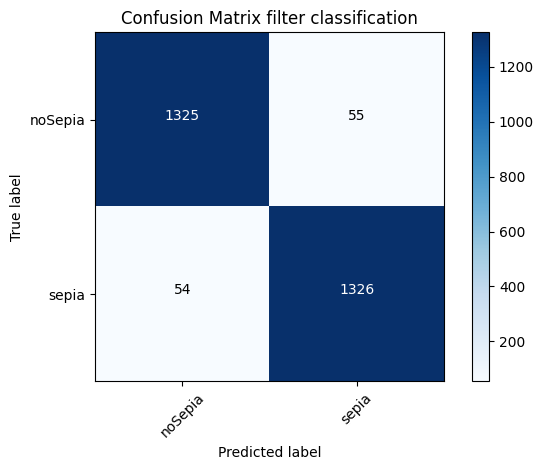

acc:  0.9605072463768116

precision: 
for sepia:  0.9601737871107893
for noSepia:  0.9608411892675852

recall: 
for sepia:  0.9608695652173913
for noSepia:  0.9601449275362319


In [7]:
def plotConfusionMatrix(cm, classNames, title):
    from sklearn.metrics import confusion_matrix
    import itertools

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                horizontalalignment = 'center',
                color = 'white' if cm[row, column] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

def evalMultiClass(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix

    confMatrix = confusion_matrix(realLabels, computedLabels)
    acc = sum([confMatrix[i][i] for i in range(len(labelNames))]) / len(realLabels)
    precision = {}
    recall = {}
    for i in range(len(labelNames)):
        precision[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[j][i] for j in range(len(labelNames))])
        recall[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[i][j] for j in range(len(labelNames))])
    return acc, precision, recall, confMatrix


acc, prec, recall, cm = evalMultiClass(np.array(testOutputs), predictedLabels, outputNames)


plotConfusionMatrix(cm, outputNames, "filter classification")
print('acc: ', acc)

print('\nprecision: ')
print('for sepia: ',prec['sepia'])
print('for noSepia: ', prec['noSepia'])

print('\nrecall: ')
print('for sepia: ',recall['sepia'])
print('for noSepia: ', recall['noSepia'])